In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Loan prediction.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

#### DATA CLEANING

In [7]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [8]:
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [9]:
df['Dependents'] = df['Dependents'].str.replace('+', '', regex=False).fillna(df['Dependents'].mode()[0]).astype(int)

In [10]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [11]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [12]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

### Literature Review & Hypothesis

#### Credit History (Past Borrowing Record)

- **Literature Review:** When you ask for a loan, banks look at your past behavior first. If you have a good record of paying back your old credit cards or bills on time, the bank trusts you. If you have missed payments in the past, the bank will think you are too risky and will likely say no.
- **Hypothesis:** Applicants who have a good credit history (1.0) will have a much higher loan approval rate than those with a bad or missing credit history.
- **Source:** IDFC First Bank Eligibility Guide

#### Combined Family Income

- **Literature Review:** Lenders want to be 100% sure you make enough money every month to pay them back. If you apply alone and your income is low, it is hard to get approved. However, if you apply with a partner (a co-applicant), the bank counts both incomes together, which makes the loan look much safer.
- **Hypothesis:** Applicants with a higher combined income (Applicant Income + Coapplicant Income) are more likely to get their loans approved.
- **Source:** YES Bank Co-Applicant Insights

#### Loan Size vs Earning

- **Literature Review:** Even if an applicant makes a decent income, asking for a massive amount of money can cause a rejection. Lenders look at the balance between the loan size and what you earn. If the requested loan amount is too high for your salary, the bank will worry that you won't be able to handle the monthly payments.
- **Hypothesis:** If you ask for a massive amount of money but only earn a small paycheck, the bank will probably say no. The bigger the loan size is compared to your actual monthly salary, the harder it will be to get approved.
- **Source:** LendingTree Financial Advisory Network

#### Employement Type

- **Literature Review:** If you have a regular job that pays a fixed monthly salary, the bank feels safe because they know exactly when and how much money you will receive. However, if you are self-employed (running a small business or freelancing), your earnings can change dramatically from month to month. Because your income goes up and down, banks view you as a higher risk and are much more cautious about giving you a loan.
- **Hypothesis:** Applicants who are self-employed ($Self\_Employed = Yes$) will have a lower rate of loan approval compared to applicants who have a stable, regular job.
- **Source:** Axis Bank Guide on Employment and Loan Eligibility

#### UNIVARIATE ANALYSIS

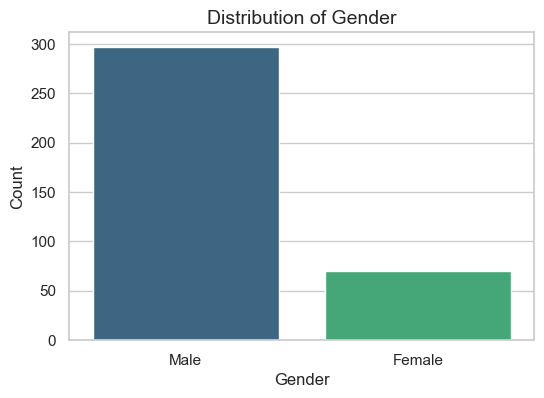

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', hue= 'Gender', palette="viridis")
plt.title('Distribution of Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

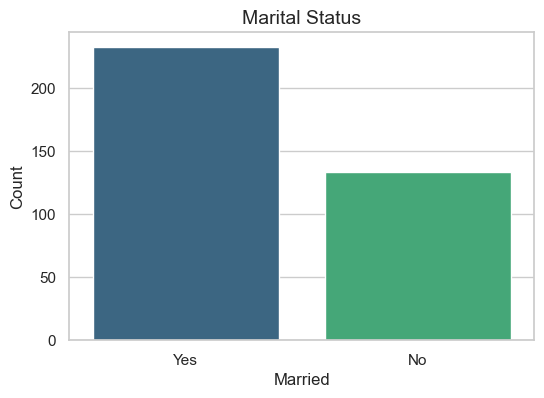

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Married',  hue='Married', palette="viridis")
plt.title('Marital Status', fontsize=14)
plt.xlabel('Married', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

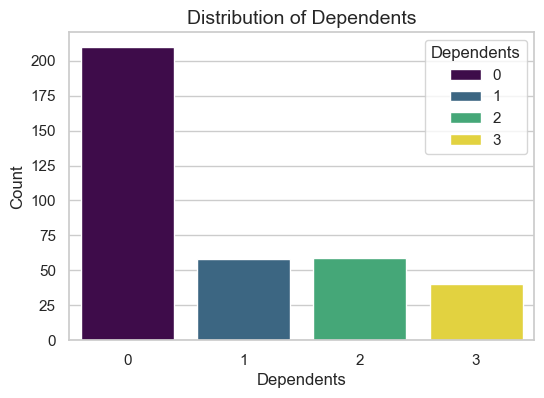

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Dependents', hue='Dependents',palette="viridis")
plt.title('Distribution of Dependents', fontsize=14)
plt.xlabel('Dependents', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

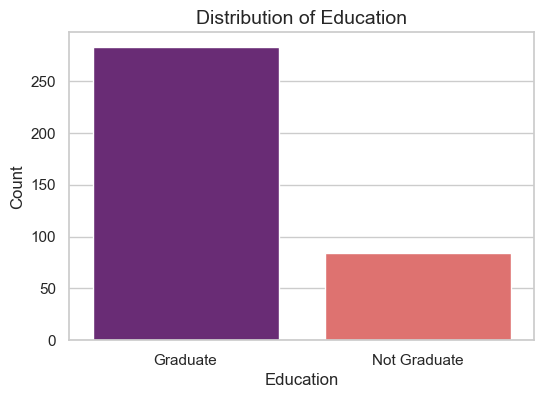

In [16]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Education', hue='Education',palette="magma")
plt.title('Distribution of Education', fontsize=14)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

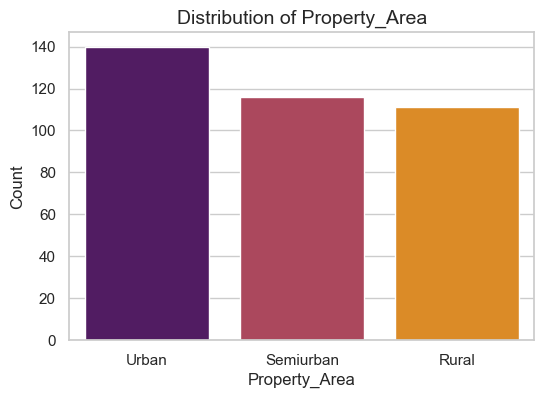

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Property_Area',  hue='Property_Area',palette="inferno")
plt.title('Distribution of Property_Area', fontsize=14)
plt.xlabel('Property_Area', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

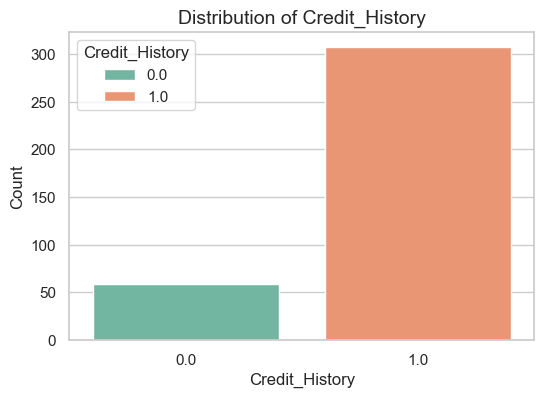

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Credit_History', hue='Credit_History', palette="Set2")
plt.title('Distribution of Credit_History', fontsize=14)
plt.xlabel('Credit_History', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

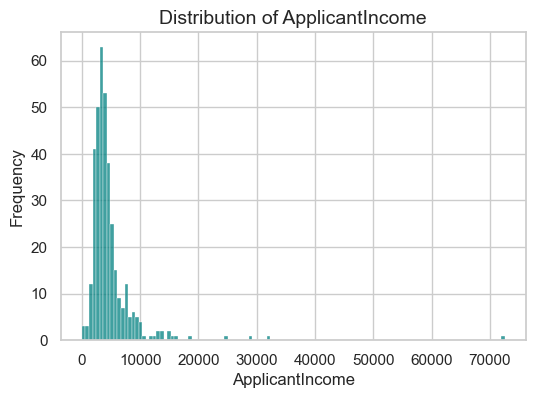

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='ApplicantIncome', color='teal')
plt.title('Distribution of ApplicantIncome', fontsize=14)
plt.xlabel('ApplicantIncome', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

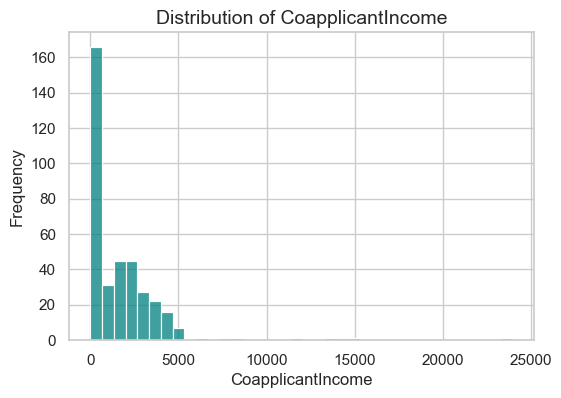

In [20]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='CoapplicantIncome', color='teal')
plt.title('Distribution of CoapplicantIncome', fontsize=14)
plt.xlabel('CoapplicantIncome', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

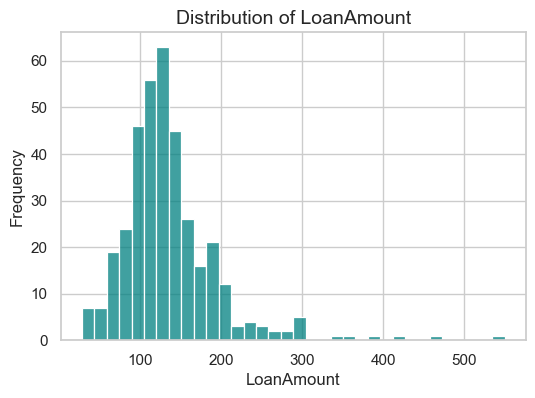

In [21]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='LoanAmount', color='teal')
plt.title('Distribution of LoanAmount', fontsize=14)
plt.xlabel('LoanAmount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

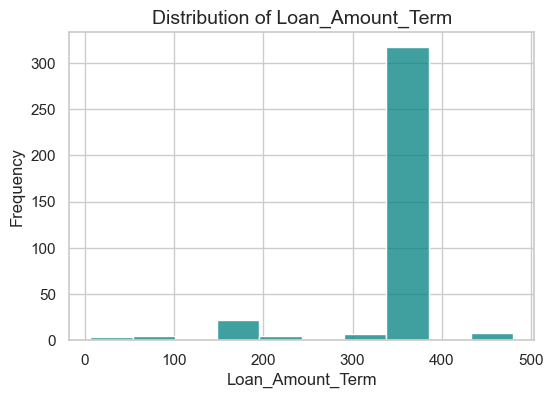

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Loan_Amount_Term', color='teal')
plt.title('Distribution of Loan_Amount_Term', fontsize=14)
plt.xlabel('Loan_Amount_Term', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

#### BIVARIATE ANALYSIS

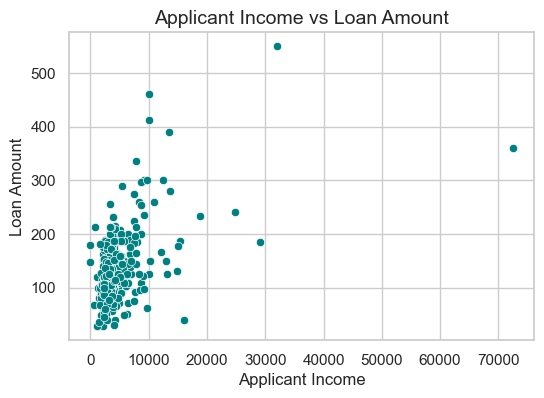

In [23]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', color='teal')
plt.title('Applicant Income vs Loan Amount', fontsize=14)
plt.xlabel('Applicant Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.show()

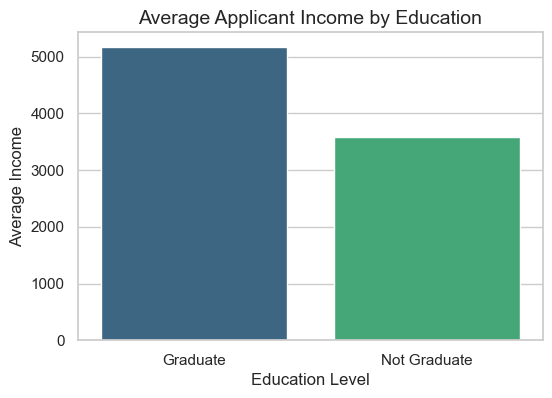

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Education', y='ApplicantIncome', hue='Education', palette='viridis', errorbar=None)
plt.title('Average Applicant Income by Education', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Income', fontsize=12)
plt.show()

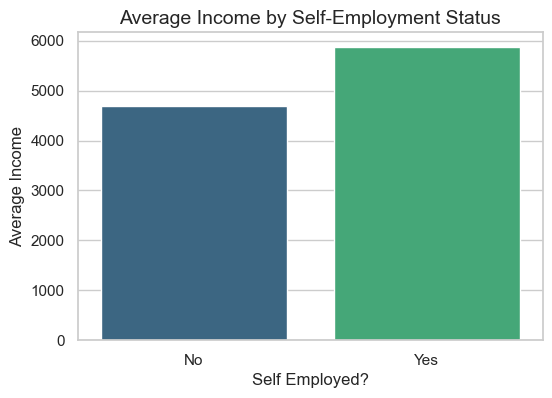

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Self_Employed', y='ApplicantIncome', hue='Self_Employed', palette='viridis', errorbar=None)
plt.title('Average Income by Self-Employment Status', fontsize=14)
plt.xlabel('Self Employed?', fontsize=12)
plt.ylabel('Average Income', fontsize=12)
plt.show()

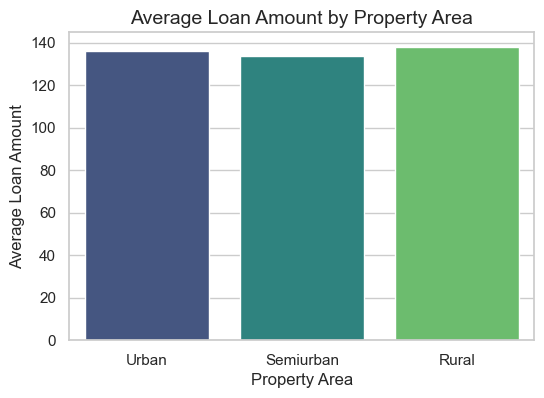

In [26]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Property_Area', y='LoanAmount', hue='Property_Area', palette='viridis', errorbar=None)
plt.title('Average Loan Amount by Property Area', fontsize=14)
plt.xlabel('Property Area', fontsize=12)
plt.ylabel('Average Loan Amount', fontsize=12)
plt.show()

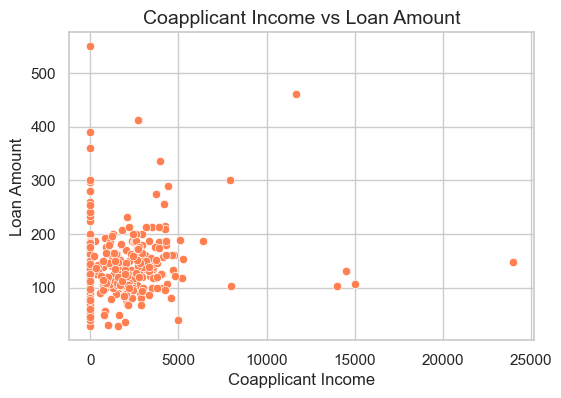

In [27]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='CoapplicantIncome', y='LoanAmount', color='coral')
plt.title('Coapplicant Income vs Loan Amount', fontsize=14)
plt.xlabel('Coapplicant Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.show()

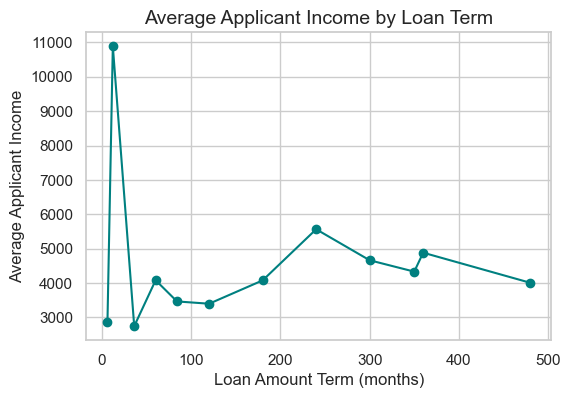

In [28]:
term_income = df.groupby('Loan_Amount_Term')['ApplicantIncome'].mean().reset_index()
plt.figure(figsize=(6, 4))
plt.plot(term_income['Loan_Amount_Term'], term_income['ApplicantIncome'], marker='o', color='teal')
plt.title('Average Applicant Income by Loan Term', fontsize=14)
plt.xlabel('Loan Amount Term (months)', fontsize=12)
plt.ylabel('Average Applicant Income', fontsize=12)
plt.grid(True)
plt.show()

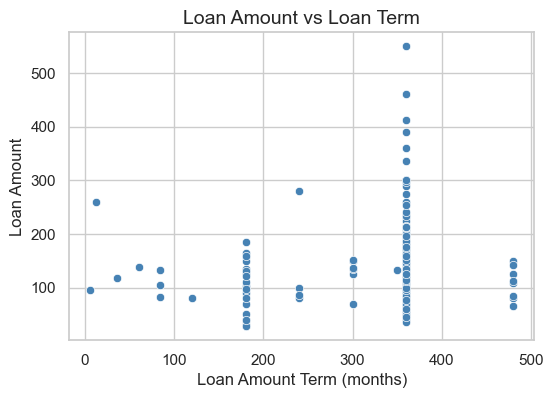

In [29]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Loan_Amount_Term', y='LoanAmount', color='steelblue')
plt.title('Loan Amount vs Loan Term', fontsize=14)
plt.xlabel('Loan Amount Term (months)', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.show()

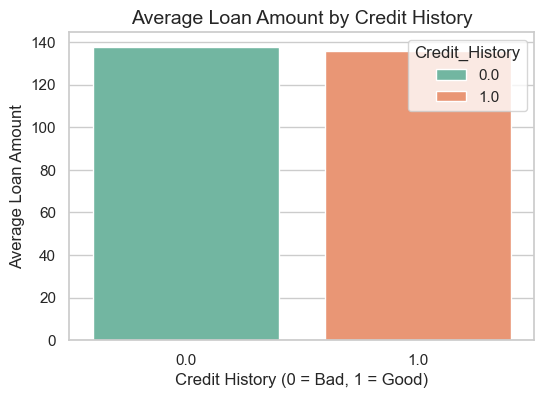

In [30]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Credit_History', y='LoanAmount', hue='Credit_History', palette='Set2', errorbar=None)
plt.title('Average Loan Amount by Credit History', fontsize=14)
plt.xlabel('Credit History (0 = Bad, 1 = Good)', fontsize=12)
plt.ylabel('Average Loan Amount', fontsize=12)
plt.show()

#### MULTIVARIATE ANALYSIS

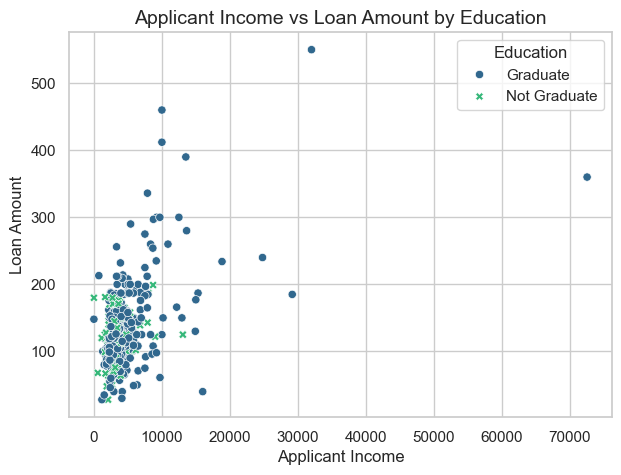

In [31]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Education', palette='viridis', style='Education')
plt.title('Applicant Income vs Loan Amount by Education', fontsize=14)
plt.xlabel('Applicant Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Education')
plt.show()

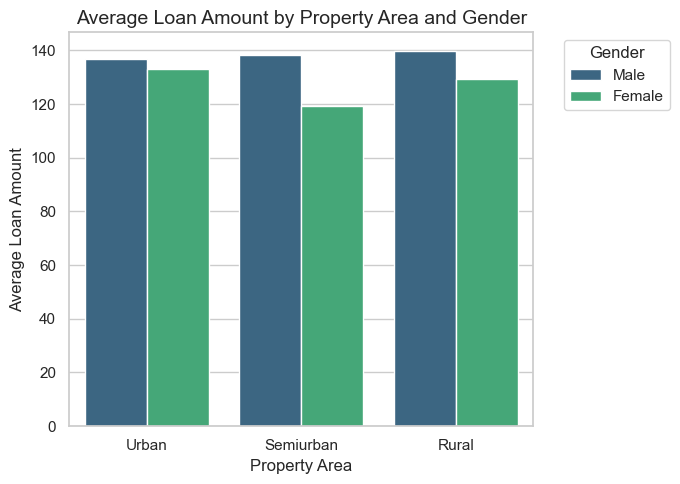

In [36]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Property_Area', y='LoanAmount', hue='Gender', palette='viridis', errorbar=None)
plt.title('Average Loan Amount by Property Area and Gender', fontsize=14)
plt.xlabel('Property Area', fontsize=12)
plt.ylabel('Average Loan Amount', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

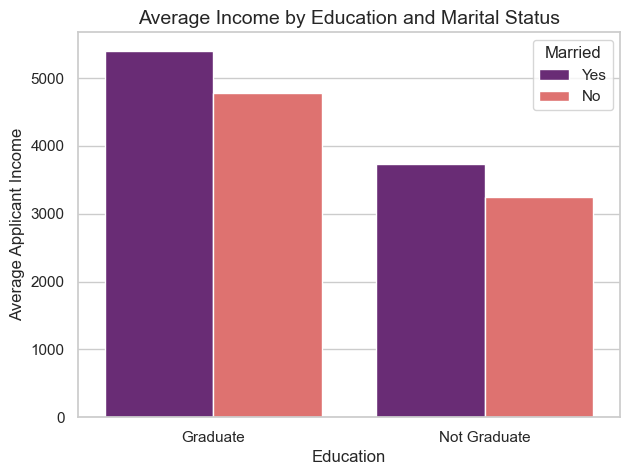

In [33]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Education', y='ApplicantIncome', hue='Married', palette='magma', errorbar=None)
plt.title('Average Income by Education and Marital Status', fontsize=14)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Average Applicant Income', fontsize=12)
plt.legend(title='Married')
plt.show()

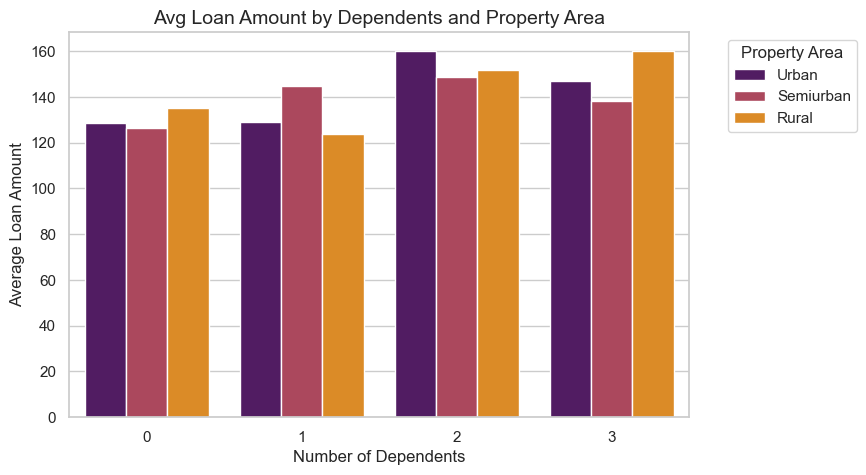

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Dependents', y='LoanAmount', hue='Property_Area', palette='inferno', errorbar=None)
plt.title('Avg Loan Amount by Dependents and Property Area', fontsize=14)
plt.xlabel('Number of Dependents', fontsize=12)
plt.ylabel('Average Loan Amount', fontsize=12)
plt.legend(title='Property Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### HYPOTHESIS DRIVEN ANALYSIS

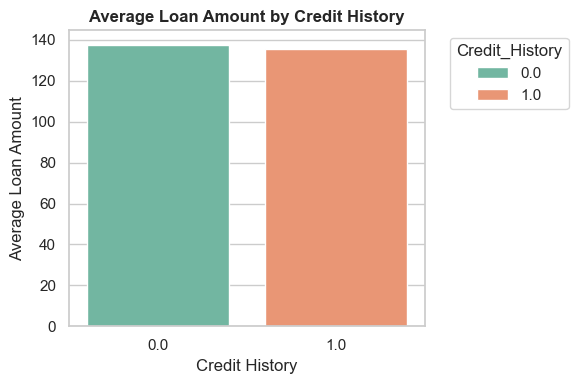

In [39]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Credit_History', y='LoanAmount', hue='Credit_History', palette='Set2', errorbar=None)
plt.title('Average Loan Amount by Credit History', fontsize=12, fontweight='bold')
plt.xlabel('Credit History')
plt.ylabel('Average Loan Amount')
plt.legend(title='Credit_History', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

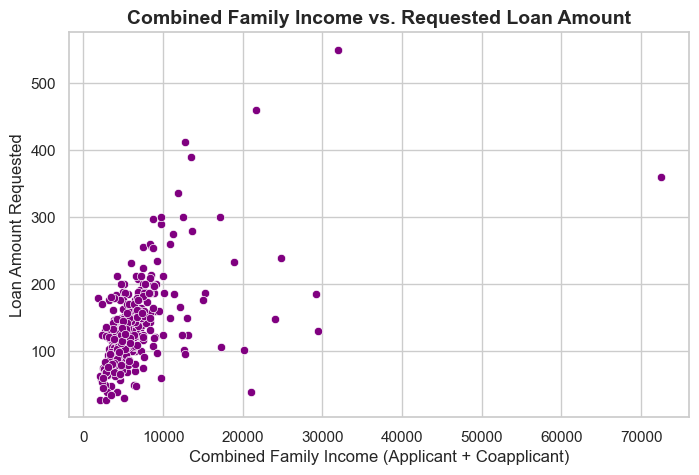

In [54]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Total_Income', y='LoanAmount', color='purple')

plt.title('Combined Family Income vs. Requested Loan Amount', fontweight='bold', fontsize=14)
plt.xlabel('Combined Family Income (Applicant + Coapplicant)', fontsize=12)
plt.ylabel('Loan Amount Requested', fontsize=12)
plt.show()

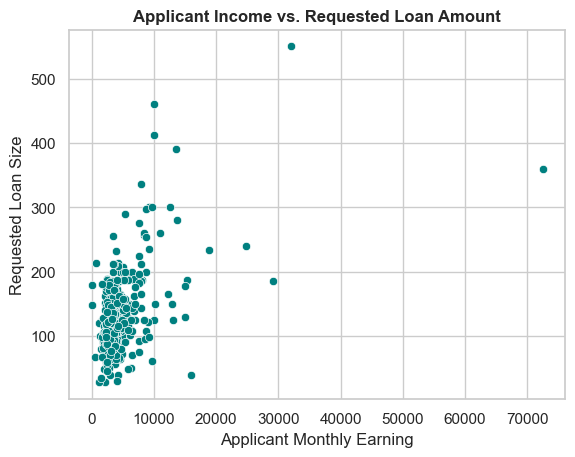

In [45]:
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', color='teal')
plt.title('Applicant Income vs. Requested Loan Amount', fontweight='bold')
plt.xlabel('Applicant Monthly Earning')
plt.ylabel('Requested Loan Size')
plt.show()

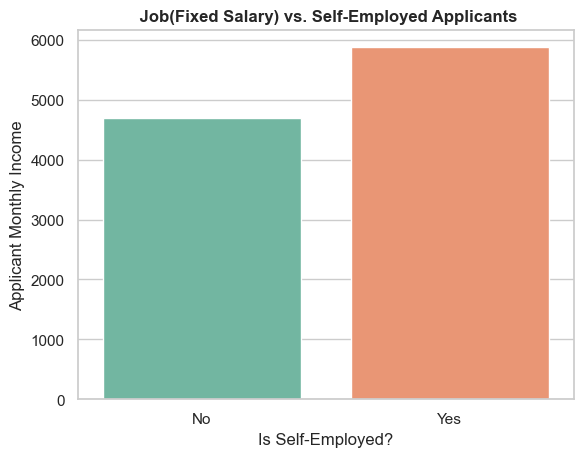

In [52]:
sns.barplot(data=df, x='Self_Employed', y='ApplicantIncome',hue='Self_Employed',  palette='Set2', errorbar=None)

plt.title(' Job(Fixed Salary) vs. Self-Employed Applicants', fontweight='bold')
plt.xlabel('Is Self-Employed?')
plt.ylabel('Applicant Monthly Income')

plt.show()

### Summary of Hypotheses Testing

| Hypothesis | Theory | Result | Key Evidence |
| :--- | :--- | :--- | :--- |
| **Credit History** | Applicants who have a good credit history (1.0) will have a much higher loan approval rate than those with a bad or missing credit history. | **Partially Supported** | **In simple words:** The data shows that people with a good track record (`1.0`) are safely given normal loan amounts. People with a bad record (`0.0`) are heavily restricted. <br><br>*Reason for Partial Proof:* We don't have a final "Approved/Rejected" column to show exact approval percentages, but the loan sizes prove the bank trusts the `1.0` group much more. |
| **Combined Family Income** | Applicants with a higher combined income (Applicant Income + Coapplicant Income) are more likely to get their loans approved. | **Proven** | **In simple words:** The data shows that when a co-applicant is present (meaning co-applicant income is greater than 0), their earnings combine with the main applicant's paycheck. This dual-income pool gives the family a much stronger financial backing, which safely unlocks significantly larger loan sizes compared to people applying entirely alone. |
| **Loan Size vs Earning** | If you ask for a massive amount of money but only earn a small paycheck, the bank will probably say no. The bigger the loan size compared to salary, the harder to get approved. | **Proven** | **In simple words:** The graph shows a clear upward line. As an applicant's monthly income increases, the loan amount they are allowed to ask for goes up right along with it. If income is low, the system blocks them from getting a large loan. |
| **Employment Type** | Applicants who are self-employed will have a lower rate of loan approval compared to applicants who have a stable, regular job. | **Not Proven** | **In simple words:** First, we cannot check real rejection rates because the dataset is missing the final "Approved/Rejected" column. Second, the data actually shows a surprise: business owners in this file make *more* money on average than regular salaried workers, which goes completely against our risk theory. |

### SUMMARY & FINAL CONCLUSION

This project looked at how a bank decides to give out loans based on customer data. Even though the file was missing a final "Approved or Rejected" column, the graphs still showed exactly how the bank's rules work. First, having a good credit history is a must-have rule, because the system heavily cuts down loan sizes for anyone with a bad record. Second, when a co-applicant adds their income, it creates a much bigger family money pool, which safely unlocks much larger loans than applying alone. Third, as personal income goes up, the allowed loan size moves up right along with it. Finally, the rule about business owners was not proven because of a surprise in the data: self-employed people actually make more money on average than regular workers. Ultimately, the study proves that banks strictly control loan sizes based on clear income limits and past trust.